In [1]:
# 03_business_kpi_analysis.ipynb
# Insurance Business Analytics Case Study: Revenue, Claims, Churn, and Customer Value

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Paths and processed data

BASE_DIR = os.getcwd()
PROCESSED_DIR = os.path.join(BASE_DIR, "data_processed")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

policy_master = pd.read_csv(os.path.join(PROCESSED_DIR, "policy_master.csv"))
ticket_ops = pd.read_csv(os.path.join(PROCESSED_DIR, "ticket_ops.csv"))
claims_kpi = pd.read_csv(os.path.join(PROCESSED_DIR, "claims_kpi_table.csv"))

print("Loaded tables:")
print("policy_master:", policy_master.shape)
print("ticket_ops:", ticket_ops.shape)
print("claims_kpi:", claims_kpi.shape)

Loaded tables:
policy_master: (1260, 56)
ticket_ops: (2418, 26)
claims_kpi: (260, 21)


In [3]:
# Type fixes

date_cols_policy = ["policy_start_date", "policy_end_date"]
for col in date_cols_policy:
    if col in policy_master.columns:
        policy_master[col] = pd.to_datetime(policy_master[col], errors="coerce")

date_cols_ticket = ["ticket_open_date", "ticket_close_date"]
for col in date_cols_ticket:
    if col in ticket_ops.columns:
        ticket_ops[col] = pd.to_datetime(ticket_ops[col], errors="coerce")

if "claim_date" in claims_kpi.columns:
    claims_kpi["claim_date"] = pd.to_datetime(claims_kpi["claim_date"], errors="coerce")

numeric_cols_policy = [
    "final_monthly_premium", "base_premium", "risk_score", "renewal_flag", "churn_flag",
    "total_premium_paid", "total_discount_amount", "total_support_cost", "total_claim_cost",
    "estimated_customer_ltv", "estimated_net_value", "ticket_count", "avg_resolution_time_hours",
    "avg_csat", "escalation_rate", "refund_rate", "total_refund_amount", "claim_count",
    "total_estimated_claim_cost", "total_approved_claim_amount", "total_discount_pct",
    "age", "tenure_months", "vehicle_year", "vehicle_value_estimate", "annual_mileage"
]
for col in numeric_cols_policy:
    if col in policy_master.columns:
        policy_master[col] = pd.to_numeric(policy_master[col], errors="coerce")

numeric_cols_ticket = [
    "resolution_time_hours", "escalation_flag", "repeat_ticket_flag",
    "csat_score", "refund_or_credit_given_flag", "refund_or_credit_amount",
    "renewal_flag", "churn_flag"
]
for col in numeric_cols_ticket:
    if col in ticket_ops.columns:
        ticket_ops[col] = pd.to_numeric(ticket_ops[col], errors="coerce")

numeric_cols_claims = [
    "estimated_claim_cost", "approved_claim_amount", "final_monthly_premium"
]
for col in numeric_cols_claims:
    if col in claims_kpi.columns:
        claims_kpi[col] = pd.to_numeric(claims_kpi[col], errors="coerce")

In [4]:
# Helper formatting

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def pct(x):
    return f"{x:.2%}"

def show_top(df, n=10, title=None):
    if title:
        print("\n" + title)
    display(df.head(n))


SECTION A — EXECUTIVE KPIs


,Metric,Value
0,Total Customers,"1,077.00"
1,Total Policies,"1,260.00"
2,Total Premium Revenue,"604,559.43"
3,Total Support Cost,"106,616.87"
4,Total Claim Cost,"390,473.78"
5,Estimated Net Value,"107,468.78"
6,Churn Rate,0.28
7,Renewal Rate,0.19


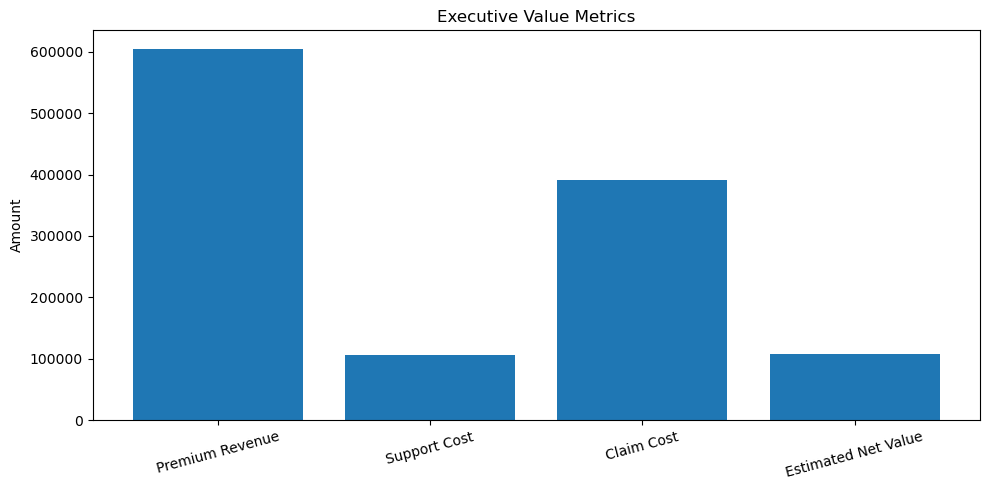

In [5]:
# Section A — Executive KPIs

total_customers = policy_master["customer_id"].nunique()
total_policies = policy_master["policy_id"].nunique()
total_premium_revenue = policy_master["total_premium_paid"].sum()
total_support_cost = policy_master["total_support_cost"].sum()
total_claim_cost = policy_master["total_claim_cost"].sum()
estimated_net_value = policy_master["estimated_net_value"].sum()
churn_rate = policy_master["churn_flag"].mean()
renewal_rate = policy_master["renewal_flag"].mean()

executive_kpis = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Policies",
        "Total Premium Revenue",
        "Total Support Cost",
        "Total Claim Cost",
        "Estimated Net Value",
        "Churn Rate",
        "Renewal Rate"
    ],
    "Value": [
        total_customers,
        total_policies,
        round(total_premium_revenue, 2),
        round(total_support_cost, 2),
        round(total_claim_cost, 2),
        round(estimated_net_value, 2),
        churn_rate,
        renewal_rate
    ]
})

print("\nSECTION A — EXECUTIVE KPIs")
display(executive_kpis)

# Simple KPI bars for the value metrics
kpi_value_df = pd.DataFrame({
    "Metric": ["Premium Revenue", "Support Cost", "Claim Cost", "Estimated Net Value"],
    "Amount": [total_premium_revenue, total_support_cost, total_claim_cost, estimated_net_value]
})

plt.figure(figsize=(10, 5))
plt.bar(kpi_value_df["Metric"], kpi_value_df["Amount"])
plt.title("Executive Value Metrics")
plt.ylabel("Amount")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


SECTION B — OPERATIONS HEALTH


,issue_type,ticket_count
5,mileage_sync_issue,330
6,payment_failure,314
7,policy_change_request,306
2,billing_issue,305
1,app_login_issue,299
0,account_update_request,289
4,discount_dispute,288
3,claim_status_question,287


,issue_type,avg_resolution_time_hours
3,claim_status_question,25.95
0,account_update_request,24.04
6,payment_failure,23.10
7,policy_change_request,22.62
4,discount_dispute,22.39
2,billing_issue,22.30
5,mileage_sync_issue,21.59
1,app_login_issue,19.60


,support_channel,avg_csat
0,chat,3.38
1,email,3.30
2,phone,3.30
3,self_service,3.08


,issue_type,escalation_rate
2,billing_issue,0.17
5,mileage_sync_issue,0.16
1,app_login_issue,0.15
3,claim_status_question,0.15
4,discount_dispute,0.15
0,account_update_request,0.13
7,policy_change_request,0.13
6,payment_failure,0.11


,issue_type,refund_rate
4,discount_dispute,0.19
7,policy_change_request,0.18
1,app_login_issue,0.17
0,account_update_request,0.15
2,billing_issue,0.14
5,mileage_sync_issue,0.12
6,payment_failure,0.12
3,claim_status_question,0.11


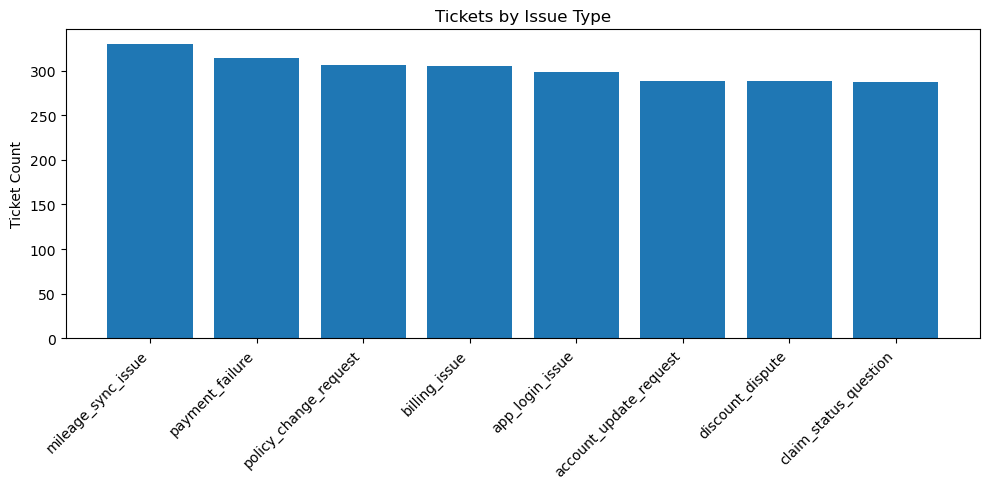

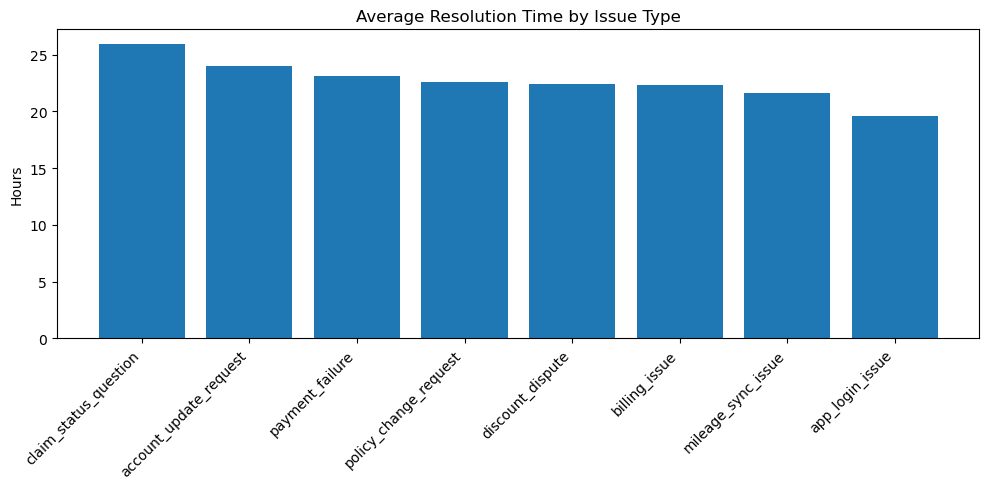

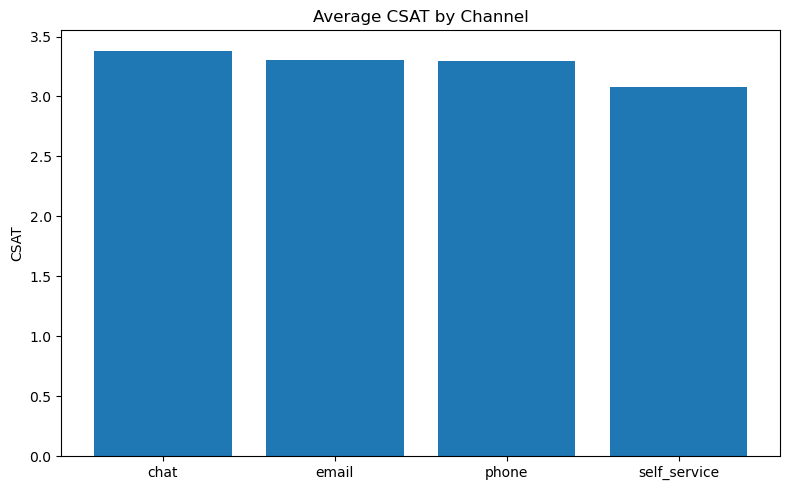

In [6]:
# Section B — Operations Health

tickets_by_issue = (
    ticket_ops.groupby("issue_type", dropna=False)
    .size()
    .reset_index(name="ticket_count")
    .sort_values("ticket_count", ascending=False)
)

avg_resolution_by_issue = (
    ticket_ops.groupby("issue_type", dropna=False)["resolution_time_hours"]
    .mean()
    .reset_index(name="avg_resolution_time_hours")
    .sort_values("avg_resolution_time_hours", ascending=False)
)

csat_by_channel = (
    ticket_ops.groupby("support_channel", dropna=False)["csat_score"]
    .mean()
    .reset_index(name="avg_csat")
    .sort_values("avg_csat", ascending=False)
)

escalation_rate_by_issue = (
    ticket_ops.groupby("issue_type", dropna=False)["escalation_flag"]
    .mean()
    .reset_index(name="escalation_rate")
    .sort_values("escalation_rate", ascending=False)
)

refund_rate_by_issue = (
    ticket_ops.groupby("issue_type", dropna=False)["refund_or_credit_given_flag"]
    .mean()
    .reset_index(name="refund_rate")
    .sort_values("refund_rate", ascending=False)
)

print("\nSECTION B — OPERATIONS HEALTH")
display(tickets_by_issue)
display(avg_resolution_by_issue)
display(csat_by_channel)
display(escalation_rate_by_issue)
display(refund_rate_by_issue)

plt.figure(figsize=(10, 5))
plt.bar(tickets_by_issue["issue_type"], tickets_by_issue["ticket_count"])
plt.title("Tickets by Issue Type")
plt.ylabel("Ticket Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(avg_resolution_by_issue["issue_type"], avg_resolution_by_issue["avg_resolution_time_hours"])
plt.title("Average Resolution Time by Issue Type")
plt.ylabel("Hours")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(csat_by_channel["support_channel"], csat_by_channel["avg_csat"])
plt.title("Average CSAT by Channel")
plt.ylabel("CSAT")
plt.tight_layout()
plt.show()


SECTION C — RISK AND CLAIMS


,claim_severity,claim_count
1,low,150
2,medium,85
0,high,25


,vehicle_type,total_claim_cost
4,sedan,"150,460.78"
5,suv,"134,998.16"
1,hatchback,"53,054.68"
2,minivan,"19,927.12"
3,pickup,"18,079.88"
0,coupe,"13,953.16"


,policy_type,total_claim_cost
3,standard,"173,796.73"
2,premium,"103,228.52"
0,full_coverage,"63,724.23"
1,liability_only,"49,724.30"


,risk_band,avg_monthly_premium
0,high_risk,82.00
2,moderate_risk,67.66
1,low_risk,58.29


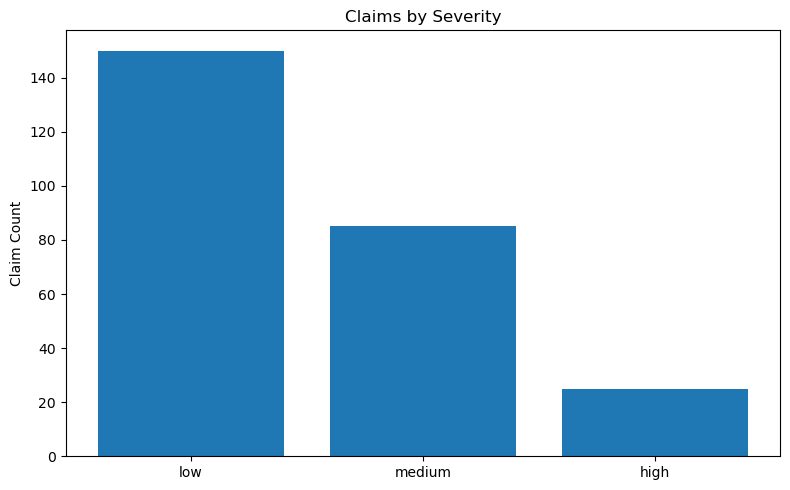

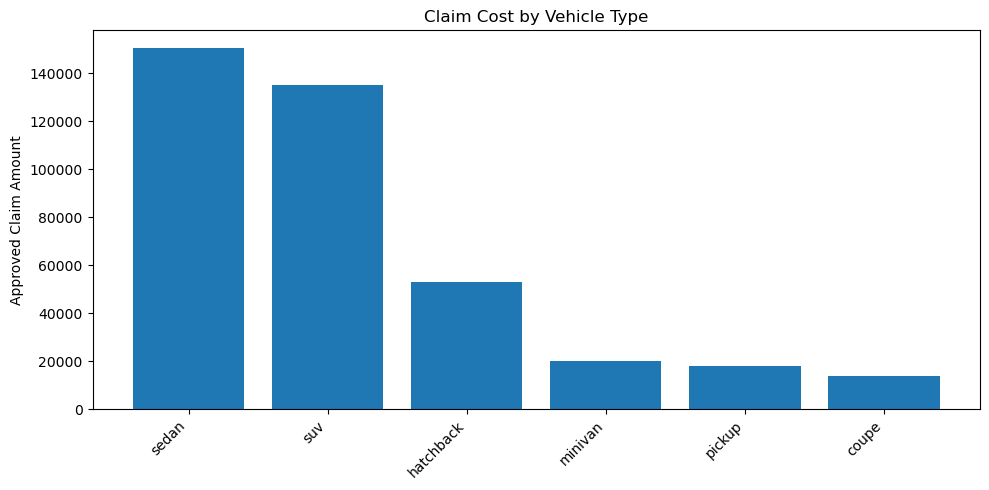

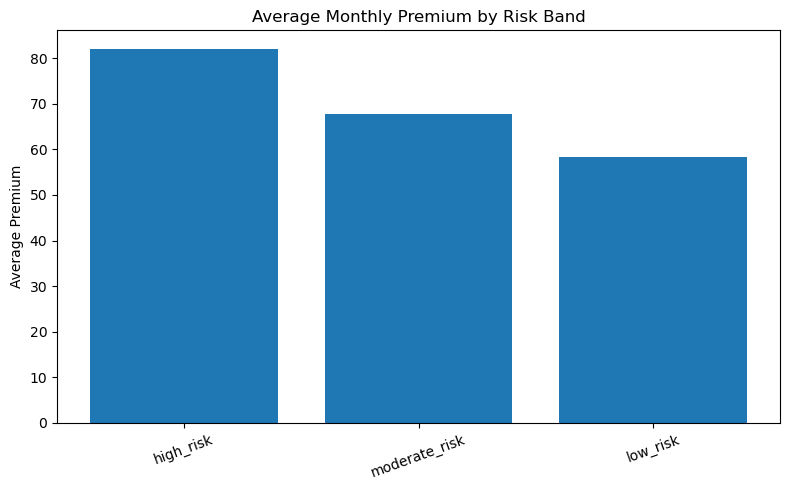

In [7]:
# Section C — Risk and Claims

claims_by_severity = (
    claims_kpi.groupby("claim_severity", dropna=False)
    .size()
    .reset_index(name="claim_count")
    .sort_values("claim_count", ascending=False)
)

claim_cost_by_vehicle_type = (
    claims_kpi.groupby("vehicle_type", dropna=False)["approved_claim_amount"]
    .sum()
    .reset_index(name="total_claim_cost")
    .sort_values("total_claim_cost", ascending=False)
)

claim_cost_by_policy_type = (
    claims_kpi.groupby("policy_type", dropna=False)["approved_claim_amount"]
    .sum()
    .reset_index(name="total_claim_cost")
    .sort_values("total_claim_cost", ascending=False)
)

risk_premium_comparison = (
    policy_master.groupby("risk_band", dropna=False)["final_monthly_premium"]
    .mean()
    .reset_index(name="avg_monthly_premium")
    .sort_values("avg_monthly_premium", ascending=False)
)

print("\nSECTION C — RISK AND CLAIMS")
display(claims_by_severity)
display(claim_cost_by_vehicle_type)
display(claim_cost_by_policy_type)
display(risk_premium_comparison)

plt.figure(figsize=(8, 5))
plt.bar(claims_by_severity["claim_severity"], claims_by_severity["claim_count"])
plt.title("Claims by Severity")
plt.ylabel("Claim Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(claim_cost_by_vehicle_type["vehicle_type"], claim_cost_by_vehicle_type["total_claim_cost"])
plt.title("Claim Cost by Vehicle Type")
plt.ylabel("Approved Claim Amount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(risk_premium_comparison["risk_band"].astype(str), risk_premium_comparison["avg_monthly_premium"])
plt.title("Average Monthly Premium by Risk Band")
plt.ylabel("Average Premium")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


SECTION D — CHURN AND RETENTION


,customer_segment,churn_rate
1,high_value,0.32
0,budget,0.31
2,premium,0.28
3,standard,0.26


,premium_band,churn_rate
3,very_high,1.00
1,low,0.29
2,mid,0.27
0,high,0.12


,support_burden_band,churn_rate
1,low,0.30
3,none,0.28
2,moderate,0.27
0,high,0.15


,discount_band,renewal_rate
1,low,0.22
2,moderate,0.20
3,none,0.20
0,high,0.18
4,very_high,0.16


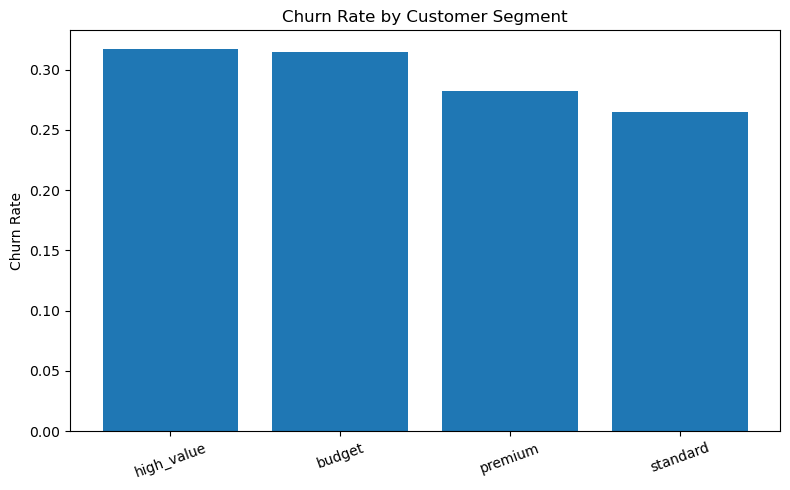

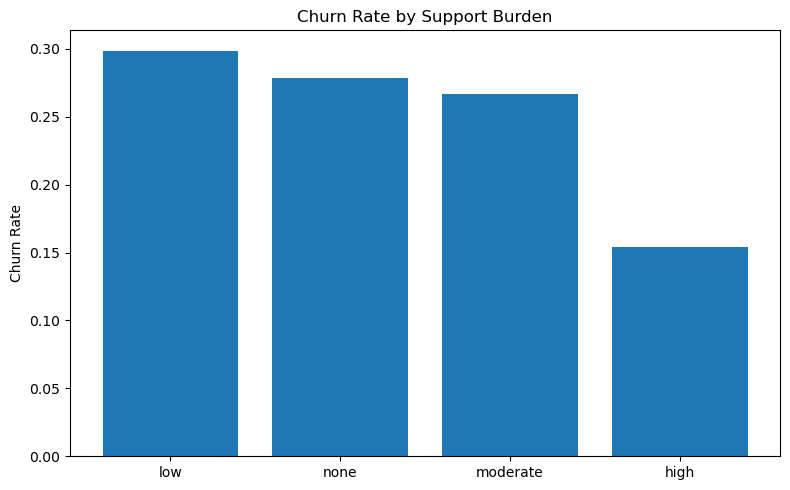

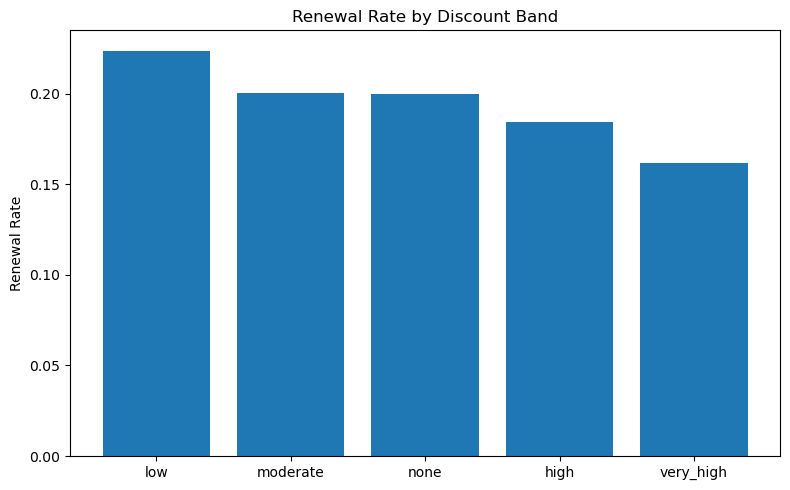

In [8]:
# Section D — Churn and Retention

churn_by_segment = (
    policy_master.groupby("customer_segment", dropna=False)["churn_flag"]
    .mean()
    .reset_index(name="churn_rate")
    .sort_values("churn_rate", ascending=False)
)

churn_by_premium_band = (
    policy_master.groupby("premium_band", dropna=False)["churn_flag"]
    .mean()
    .reset_index(name="churn_rate")
    .sort_values("churn_rate", ascending=False)
)

churn_by_support_burden = (
    policy_master.groupby("support_burden_band", dropna=False)["churn_flag"]
    .mean()
    .reset_index(name="churn_rate")
    .sort_values("churn_rate", ascending=False)
)

renewal_by_discount_band = (
    policy_master.groupby("discount_band", dropna=False)["renewal_flag"]
    .mean()
    .reset_index(name="renewal_rate")
    .sort_values("renewal_rate", ascending=False)
)

print("\nSECTION D — CHURN AND RETENTION")
display(churn_by_segment)
display(churn_by_premium_band)
display(churn_by_support_burden)
display(renewal_by_discount_band)

plt.figure(figsize=(8, 5))
plt.bar(churn_by_segment["customer_segment"], churn_by_segment["churn_rate"])
plt.title("Churn Rate by Customer Segment")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(churn_by_support_burden["support_burden_band"].astype(str), churn_by_support_burden["churn_rate"])
plt.title("Churn Rate by Support Burden")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(renewal_by_discount_band["discount_band"].astype(str), renewal_by_discount_band["renewal_rate"])
plt.title("Renewal Rate by Discount Band")
plt.ylabel("Renewal Rate")
plt.tight_layout()
plt.show()


SECTION E — PROFITABILITY


,customer_segment,avg_net_value
1,high_value,175.68
0,budget,146.01
3,standard,89.57
2,premium,-26.80


,policy_type,avg_net_value
0,full_coverage,260.03
1,liability_only,79.92
2,premium,46.83
3,standard,9.19



Negative-value customer share: 14.52%

Top customer groups by total net value


,customer_segment,policies,avg_net_value,total_net_value
3,standard,585,89.57,"52,399.96"
0,budget,305,146.01,"44,534.26"
1,high_value,101,175.68,"17,743.51"
2,premium,269,-26.80,"-7,208.94"



Bottom policy groups by total net value


,policy_type,policies,avg_net_value,total_net_value
3,standard,485,9.19,"4,456.40"
2,premium,261,46.83,"12,222.43"
1,liability_only,238,79.92,"19,021.17"
0,full_coverage,276,260.03,"71,768.79"


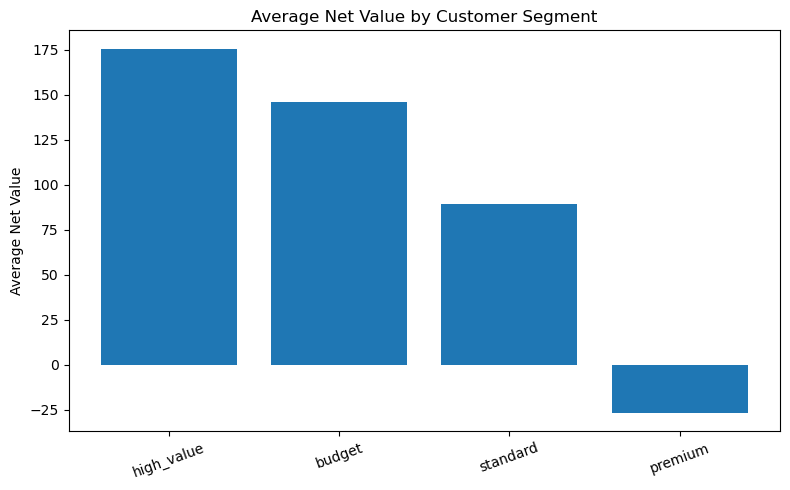

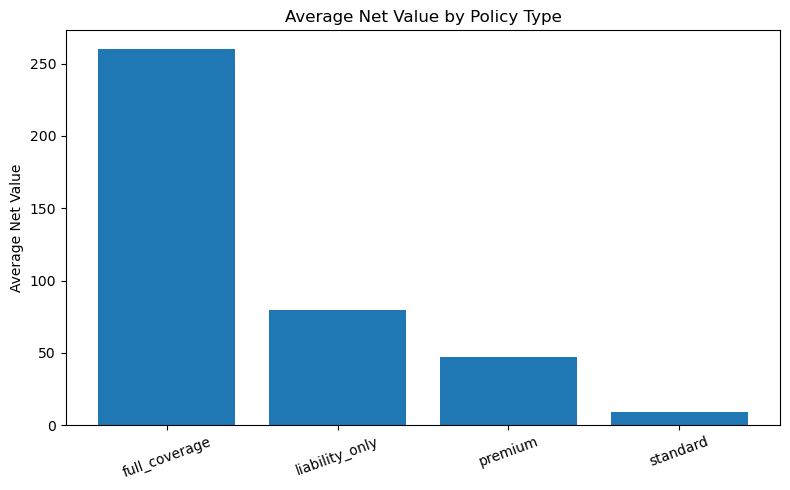

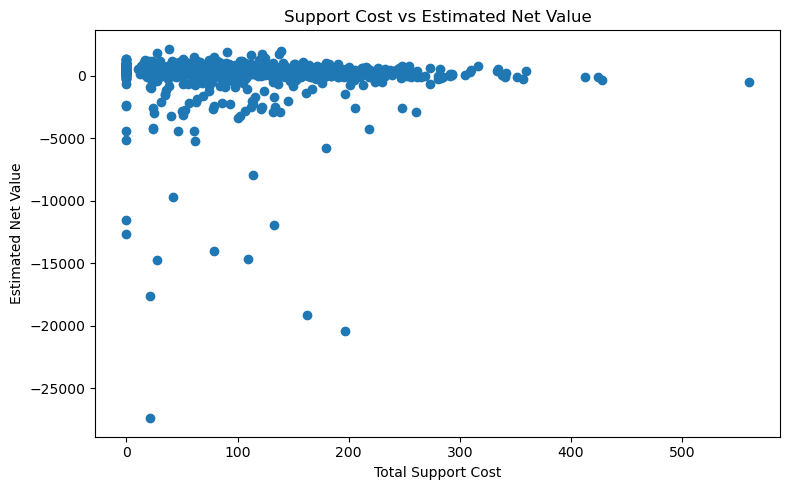

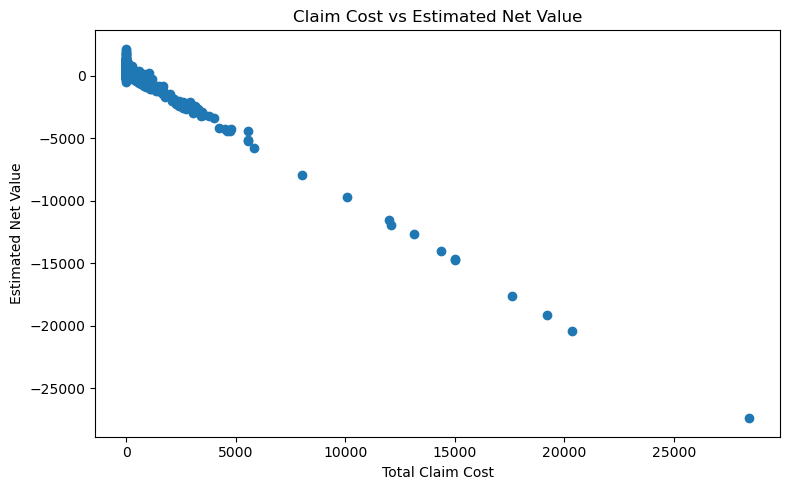

In [9]:
# Section E — Profitability

net_value_by_segment = (
    policy_master.groupby("customer_segment", dropna=False)["estimated_net_value"]
    .mean()
    .reset_index(name="avg_net_value")
    .sort_values("avg_net_value", ascending=False)
)

net_value_by_policy_type = (
    policy_master.groupby("policy_type", dropna=False)["estimated_net_value"]
    .mean()
    .reset_index(name="avg_net_value")
    .sort_values("avg_net_value", ascending=False)
)

negative_value_customer_share = (
    (policy_master["estimated_net_value"] < 0).mean()
)

top_customer_groups = (
    policy_master.groupby("customer_segment", dropna=False)
    .agg(
        policies=("policy_id", "count"),
        avg_net_value=("estimated_net_value", "mean"),
        total_net_value=("estimated_net_value", "sum")
    )
    .reset_index()
    .sort_values("total_net_value", ascending=False)
)

bottom_policy_groups = (
    policy_master.groupby("policy_type", dropna=False)
    .agg(
        policies=("policy_id", "count"),
        avg_net_value=("estimated_net_value", "mean"),
        total_net_value=("estimated_net_value", "sum")
    )
    .reset_index()
    .sort_values("total_net_value", ascending=True)
)

print("\nSECTION E — PROFITABILITY")
display(net_value_by_segment)
display(net_value_by_policy_type)

print("\nNegative-value customer share:", pct(negative_value_customer_share))

print("\nTop customer groups by total net value")
display(top_customer_groups)

print("\nBottom policy groups by total net value")
display(bottom_policy_groups)

plt.figure(figsize=(8, 5))
plt.bar(net_value_by_segment["customer_segment"], net_value_by_segment["avg_net_value"])
plt.title("Average Net Value by Customer Segment")
plt.ylabel("Average Net Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(net_value_by_policy_type["policy_type"], net_value_by_policy_type["avg_net_value"])
plt.title("Average Net Value by Policy Type")
plt.ylabel("Average Net Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Scatter: support cost vs net value
scatter_support = policy_master[["total_support_cost", "estimated_net_value"]].dropna()
plt.figure(figsize=(8, 5))
plt.scatter(scatter_support["total_support_cost"], scatter_support["estimated_net_value"])
plt.title("Support Cost vs Estimated Net Value")
plt.xlabel("Total Support Cost")
plt.ylabel("Estimated Net Value")
plt.tight_layout()
plt.show()

# Scatter: claim cost vs net value
scatter_claim = policy_master[["total_claim_cost", "estimated_net_value"]].dropna()
plt.figure(figsize=(8, 5))
plt.scatter(scatter_claim["total_claim_cost"], scatter_claim["estimated_net_value"])
plt.title("Claim Cost vs Estimated Net Value")
plt.xlabel("Total Claim Cost")
plt.ylabel("Estimated Net Value")
plt.tight_layout()
plt.show()

In [10]:
# Simple business findings

print("\nINITIAL BUSINESS FINDINGS")

highest_churn_segment = churn_by_segment.iloc[0]["customer_segment"] if len(churn_by_segment) > 0 else None
highest_churn_support = churn_by_support_burden.iloc[0]["support_burden_band"] if len(churn_by_support_burden) > 0 else None
best_net_segment = net_value_by_segment.iloc[0]["customer_segment"] if len(net_value_by_segment) > 0 else None
worst_policy_type = net_value_by_policy_type.sort_values("avg_net_value").iloc[0]["policy_type"] if len(net_value_by_policy_type) > 0 else None

print(f"- Highest churn segment: {highest_churn_segment}")
print(f"- Highest churn support-burden band: {highest_churn_support}")
print(f"- Strongest segment by average net value: {best_net_segment}")
print(f"- Weakest policy type by average net value: {worst_policy_type}")


INITIAL BUSINESS FINDINGS
- Highest churn segment: high_value
- Highest churn support-burden band: low
- Strongest segment by average net value: high_value
- Weakest policy type by average net value: standard


In [11]:
# Export summary tables for dashboard/reference

executive_kpis.to_csv(os.path.join(OUTPUTS_DIR, "executive_kpis.csv"), index=False)
tickets_by_issue.to_csv(os.path.join(OUTPUTS_DIR, "tickets_by_issue.csv"), index=False)
avg_resolution_by_issue.to_csv(os.path.join(OUTPUTS_DIR, "avg_resolution_by_issue.csv"), index=False)
csat_by_channel.to_csv(os.path.join(OUTPUTS_DIR, "csat_by_channel.csv"), index=False)
escalation_rate_by_issue.to_csv(os.path.join(OUTPUTS_DIR, "escalation_rate_by_issue.csv"), index=False)
refund_rate_by_issue.to_csv(os.path.join(OUTPUTS_DIR, "refund_rate_by_issue.csv"), index=False)

claims_by_severity.to_csv(os.path.join(OUTPUTS_DIR, "claims_by_severity.csv"), index=False)
claim_cost_by_vehicle_type.to_csv(os.path.join(OUTPUTS_DIR, "claim_cost_by_vehicle_type.csv"), index=False)
claim_cost_by_policy_type.to_csv(os.path.join(OUTPUTS_DIR, "claim_cost_by_policy_type.csv"), index=False)
risk_premium_comparison.to_csv(os.path.join(OUTPUTS_DIR, "risk_premium_comparison.csv"), index=False)

churn_by_segment.to_csv(os.path.join(OUTPUTS_DIR, "churn_by_segment.csv"), index=False)
churn_by_premium_band.to_csv(os.path.join(OUTPUTS_DIR, "churn_by_premium_band.csv"), index=False)
churn_by_support_burden.to_csv(os.path.join(OUTPUTS_DIR, "churn_by_support_burden.csv"), index=False)
renewal_by_discount_band.to_csv(os.path.join(OUTPUTS_DIR, "renewal_by_discount_band.csv"), index=False)

net_value_by_segment.to_csv(os.path.join(OUTPUTS_DIR, "net_value_by_segment.csv"), index=False)
net_value_by_policy_type.to_csv(os.path.join(OUTPUTS_DIR, "net_value_by_policy_type.csv"), index=False)
top_customer_groups.to_csv(os.path.join(OUTPUTS_DIR, "top_customer_groups.csv"), index=False)
bottom_policy_groups.to_csv(os.path.join(OUTPUTS_DIR, "bottom_policy_groups.csv"), index=False)

print("\nSummary tables saved to:", OUTPUTS_DIR)


Summary tables saved to: C:\Users\thebe\OneDrive\Desktop\IsuranceDA\outputs
